In [107]:
import pandas as pd
import numpy as np

sentiment_df = pd.read_csv(
    "../data/processed/customer_support_sentiment.csv"
)

print("Rows:", sentiment_df.shape[0])
print("Columns:", sentiment_df.shape[1])

Rows: 28742
Columns: 25


In [108]:
sentiment_df.head()

,unique_id,channel_name,category,sub_category,customer_remarks,order_id,order_date_time,issue_reported_at,issue_responded,survey_response_date,...,manager,tenure_bucket,agent_shift,csat_score,response_time_minutes,response_time_bucket,csat_category,has_customer_remark,has_order_info,has_response_time
0,372b51a5-fa19-4a31-a4b8-a21de117d75e,inbound,Returns,Exchange / Replacement,Very good,88537e0b-5ffa-43f9-bbe2-fe57a0f4e4ae,NaN,2023-01-08 16:17:00,2023-01-08 16:23:00,2023-08-01,...,Jennifer Nguyen,On Job Training,Evening,5,6.0,<15 min,Satisfied,True,True,True
1,6e4413db-4e16-42fc-ac92-2f402e3df03c,inbound,Returns,Missing,Shopzilla app and it's all coustomer care services is very good service provided all time,e6be9713-13c3-493c-8a91-2137cbbfa7e6,NaN,2023-01-08 21:03:00,2023-01-08 21:07:00,2023-08-01,...,John Smith,>90,Split,5,4.0,<15 min,Satisfied,True,True,True
2,4c28acf4-2ea4-4be8-b8f1-113e676fc8b7,inbound,Order Related,Delayed,Very bad,55bbace3-eb2e-4f67-aacb-4f8ee8512f75,2023-07-19 23:50:00,2023-02-08 10:44:00,2023-02-08 11:14:00,2023-08-02,...,Emily Chen,>90,Split,1,30.0,15–30 min,Dissatisfied,True,True,True
3,c54459b3-ffb3-4ffa-a338-6fd179beb6b1,inbound,Order Related,Installation/demo,Something,0cdaa1f1-02f2-40ec-9134-7cd0f92a6b3e,NaN,2023-01-08 10:00:00,2023-01-08 10:04:00,2023-08-01,...,William Kim,On Job Training,Morning,3,4.0,<15 min,Neutral,True,True,True
4,6e51734e-9627-4a12-8062-877c3638627d,inbound,Order Related,Installation/demo,All good,8a1ae638-4d8c-4a5e-bf1b-eb74f881fc3d,2023-07-18 12:20:00,2023-02-08 20:03:00,2023-02-08 20:05:00,2023-08-02,...,Emily Chen,31-60,Evening,5,2.0,<15 min,Satisfied,True,True,True


In [109]:
sentiment_df["customer_remarks"].head(20)

0                                                                                                                                                                                                                                                                            Very good
1                                                                                                                                                                                            Shopzilla app and it's all coustomer care services is very good service provided all time
2                                                                                                                                                                                                                                                                             Very bad
3                                                                                                                                                                  

In [110]:
pd.set_option("display.max_colwidth", 300)

display(
    sentiment_df[
        ["customer_remarks", "csat_score", "category"]
    ].head(20)
)

,customer_remarks,csat_score,category
0,Very good,5,Returns
1,Shopzilla app and it's all coustomer care services is very good service provided all time,5,Returns
2,Very bad,1,Order Related
3,Something,3,Order Related
4,All good,5,Order Related
5,Good,5,Returns
6,Godd job,5,Payments related
7,Issue not resolved pathetic service,1,Order Related
8,Excellent,5,Returns
9,Very good,4,Cancellation


In [111]:
sentiment_df["customer_remarks"].isna().sum()

np.int64(3)

In [112]:
sentiment_df = sentiment_df.dropna(subset=["customer_remarks"])

In [113]:
sentiment_df["customer_remarks"].isna().sum()

np.int64(0)

In [114]:
(sentiment_df["customer_remarks"].str.strip() == "").sum()

np.int64(0)

installation of vader

In [115]:
import nltk
print(nltk.__version__)

3.10.2


In [116]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\ky582\AppData\Local\Python\pythoncore-3.14-64\python.exe
3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [117]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

print("VADER is working!")

VADER is working!


In [118]:
text = "My order is extremely late and nobody is helping me."

print(sia.polarity_scores(text))

{'neg': 0.0, 'neu': 0.804, 'pos': 0.196, 'compound': 0.296}


In [119]:
test_messages = [
    "I am very happy with the service.",
    "My order arrived late and I am extremely disappointed.",
    "The product is okay."
]

for message in test_messages:
    print(message)
    print(sia.polarity_scores(message))
    print()

I am very happy with the service.
{'neg': 0.0, 'neu': 0.6, 'pos': 0.4, 'compound': 0.6115}

My order arrived late and I am extremely disappointed.
{'neg': 0.298, 'neu': 0.702, 'pos': 0.0, 'compound': -0.5256}

The product is okay.
{'neg': 0.0, 'neu': 0.612, 'pos': 0.388, 'compound': 0.2263}



In [120]:
def get_sentiment_score(text):
    return sia.polarity_scores(text)["compound"]

In [121]:
get_sentiment_score(
    "My order is extremely late and nobody is helping me"
)

0.296

In [122]:
sentiment_df["sentiment_score"] = (
    sentiment_df["customer_remarks"]
    .apply(get_sentiment_score)
)

In [123]:
sentiment_df[
    ["customer_remarks", "sentiment_score"]
].head(20)

,customer_remarks,sentiment_score
0,Very good,0.4927
1,Shopzilla app and it's all coustomer care services is very good service provided all time,0.7501
2,Very bad,-0.5849
3,Something,0.0000
4,All good,0.4404
5,Good,0.4404
6,Godd job,0.0000
7,Issue not resolved pathetic service,0.3570
8,Excellent,0.5719
9,Very good,0.4927


In [124]:
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [125]:
sentiment_df["sentiment"] = (
    sentiment_df["sentiment_score"]
    .apply(classify_sentiment)
)

In [126]:
sentiment_df[
    ["customer_remarks", "sentiment_score", "sentiment"]
].head(20)

,customer_remarks,sentiment_score,sentiment
0,Very good,0.4927,Positive
1,Shopzilla app and it's all coustomer care services is very good service provided all time,0.7501,Positive
2,Very bad,-0.5849,Negative
3,Something,0.0000,Neutral
4,All good,0.4404,Positive
5,Good,0.4404,Positive
6,Godd job,0.0000,Neutral
7,Issue not resolved pathetic service,0.3570,Positive
8,Excellent,0.5719,Positive
9,Very good,0.4927,Positive


In [127]:
sentiment_df["sentiment"].value_counts()

sentiment
Positive    18977
Neutral      4903
Negative     4859
Name: count, dtype: int64

In [128]:
sentiment_distribution = (
    sentiment_df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_distribution)

sentiment
Positive    66.03
Neutral     17.06
Negative    16.91
Name: proportion, dtype: float64


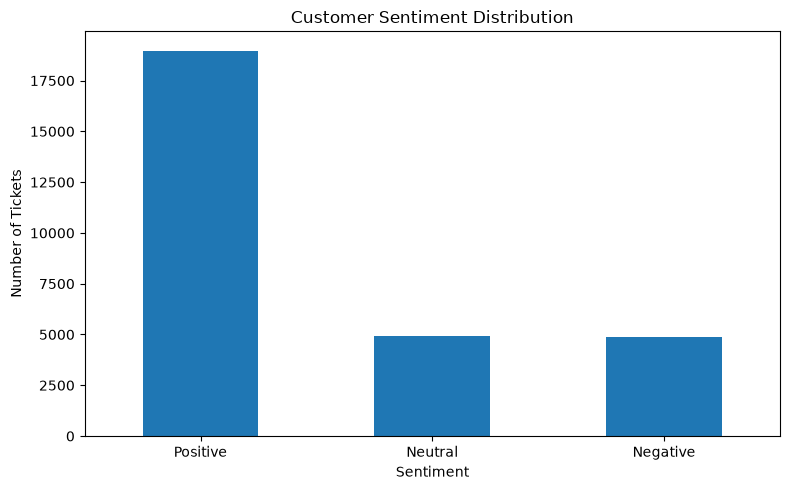

In [129]:
import matplotlib.pyplot as plt

sentiment_counts = sentiment_df["sentiment"].value_counts()

plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind="bar")
plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [130]:
sentiment_by_category = pd.crosstab(
    sentiment_df["category"],
    sentiment_df["sentiment"],
    normalize="index"
) * 100

sentiment_by_category = sentiment_by_category.round(2)

display(sentiment_by_category)

sentiment,Negative,Neutral,Positive
category,,,
App/website,27.27,9.09,63.64
Cancellation,20.25,17.89,61.86
Feedback,20.18,17.62,62.20
Offers & Cashback,15.97,18.06,65.97
Onboarding related,16.13,19.35,64.52
Order Related,19.53,18.86,61.61
Others,26.19,14.29,59.52
Payments related,14.10,13.21,72.69
Product Queries,21.45,19.66,58.89


In [131]:
negative_by_category = (
    sentiment_df
    .groupby("category")["sentiment_score"]
    .mean()
    .sort_values()
)

display(negative_by_category)

category
Others                0.193331
Product Queries       0.194220
Cancellation          0.208150
Order Related         0.212129
Feedback              0.214366
App/website           0.220645
Refund Related        0.263661
Offers & Cashback     0.270631
Returns               0.276048
Shopzilla Related     0.299813
Payments related      0.304408
Onboarding related    0.318203
Name: sentiment_score, dtype: float64

In [132]:
negative_rate = (
    sentiment_df.assign(
        is_negative=sentiment_df["sentiment"] == "Negative"
    )
    .groupby("category")["is_negative"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

display(negative_rate)

category
App/website           27.27
Others                26.19
Product Queries       21.45
Cancellation          20.25
Feedback              20.18
Order Related         19.53
Onboarding related    16.13
Offers & Cashback     15.97
Returns               15.36
Shopzilla Related     14.48
Refund Related        14.39
Payments related      14.10
Name: is_negative, dtype: float64

In [133]:
sentiment_csat = (
    sentiment_df
    .groupby("sentiment")["csat_score"]
    .agg(["count", "mean"])
    .round(2)
)

display(sentiment_csat)

,count,mean
sentiment,,
Negative,4859,2.39
Neutral,4903,3.72
Positive,18977,4.59


In [134]:
sentiment_df[
    ["sentiment", "response_time_minutes"]
].groupby("sentiment").mean().round(2)

,response_time_minutes
sentiment,
Negative,7200.94
Neutral,5419.66
Positive,3473.74


In [135]:
response_sentiment = pd.crosstab(
    sentiment_df["response_time_bucket"],
    sentiment_df["sentiment"],
    normalize="index"
) * 100

display(response_sentiment.round(2))

sentiment,Negative,Neutral,Positive
response_time_bucket,,,
15–30 min,23.03,16.95,60.03
1–4 hours,27.36,18.24,54.39
24+ hours,28.36,19.03,52.61
30–60 min,23.19,16.47,60.34
4–24 hours,25.23,17.99,56.78
<15 min,13.29,17.13,69.58


In [136]:
most_negative = (
    sentiment_df
    .sort_values("sentiment_score")
    [["customer_remarks", "sentiment_score", "category", "csat_score"]]
    .head(20)
)

display(most_negative)

,customer_remarks,sentiment_score,category,csat_score
4335,Worst worst worst worst Worst worst worst worst Worst worst worst worst Worst worst worst worst experience,-0.9970,Order Related,1
15469,"Very bed, disgusting, unprofessional, online shopping fraud, unacceptable, you are habitual offenders on offers of Exchanges, when you are not willing to accept why did showing options at the time of order booking. Issue you mentioned wrong no address pincode miss match. You offer an exchange of...",-0.9881,Order Related,1
13038,"Shopzilla is the worst thing thats happening right now , The refunds or returns are very easy with SuperBuy but i dont know why its really difficult with Shopzilla they ask for proofs, even when we share proofs also they are not willing to accept for the refund process. I already told them that ...",-0.9845,Returns,1
2077,": Unresolved Issue and Formal NoticeDear Sir/Madam, I am writing to bring to your attention the ongoing issue I have been facing with my recent purchase from Shopzilla. My order was placed on 15th of July, and since then, I have been diligently trying to connect with your customer service team e...",-0.9833,Returns,1
13260,"execuitive is good, experienced and well mannered. but no service by Shopzilla since 01/08/2023. So Shopzilla GO TO HELL and DESTROY IMMEDIATELY. STOP SUCH FRAUD BUSINESS.",-0.9815,Order Related,5
25269,Executive which I talked recently is very polite and nice. But Shopzilla service is very worst. Worst customer centric organization. Worst company and worst policy eed to be changed.,-0.9786,Product Queries,5
5427,"You've sent us a messageToday, Aug 07 05:20 AMDear Shopzilla, i got damage and defective item on 20july2023. Same day I requested for return and need replacement. My replacement order came on 25 july 2023but delivery boy denied for delivering. He told we have to come in their office for collecti...",-0.9785,Returns,1
6313,Its two lights are blinking [page light and ink light ] simultaneously which means ink pad is about end of its service life As per its user manual . But i brought today how can it possible means it is a defective productIt is a defective productProblem in its inner part how can i take photo of i...,-0.9778,Order Related,1
12029,"Junior executive was very polite but senior executive was very rude and unhelpful, giving false and misleading information, giving fake details, behaving rude and doing things as per his own opinion. These executives should immediately fired from such workplaces. Very very disappointed with the ...",-0.9778,Order Related,1
1979,"Your executives are lying, they told me before placing the order that you can send us an email for adding your gstin after the order is placed and we can update it backend, and now your executives are saying that I was provided with wrongful information, no such provision exists. Now I am bearin...",-0.9771,Order Related,1


In [137]:
most_positive = (
    sentiment_df
    .sort_values("sentiment_score", ascending=False)
    [["customer_remarks", "sentiment_score", "category", "csat_score"]]
    .head(20)
)

display(most_positive)

,customer_remarks,sentiment_score,category,csat_score
14663,Customer care manage super You talking as very nice and properly it's voice also very nice and he is very good to talk with everyone Shopzilla thank you for help me in best I am very happy from that man who help me this customer care man from me for customer care 5 out of 5 star thanks,0.9911,Refund Related,5
4597,Thank you so much for helping me to refund my money... Customer was really good ... I thank him because he handle my problem is really good and polite.. he really supportive and share each and every single word is help me to understandble.. thank you so much to him ... He's really blessed...and ...,0.9852,Returns,5
1871,"I speak with on 2 Aug and today 3rd August with a , don't know his name ..But both of them were quick and helpful. I like the service and the one guy who helped me today to raise a return request. Thank you ?? for hiring such good candidates. Please appreciate the one who called me on 3rd Aug...",0.9839,Returns,5
24672,The sale consultant was polite and helpful possess excellent knowledge of her job . She very well understood my issue and solved it as expected. I am satisfied. She also assured me of best of services from Shopzilla. Thank you Shopzilla for appointing such a mature lady to make my shopping exper...,0.9810,Order Related,5
270,"I didn't received the the product one out of two. Very frustrated .Please understand that my frustration is not directed at you personally, but rather at the lack of attention and assistance from your customer service representatives. I believe that a reputable company like yours should prioriti...",0.9810,Returns,1
26365,"I was facing an issue that had been bothering me, and I decided to reach out to your customer care. I was pleasantly surprised by the swift and effective resolution provided by your team. Their attentiveness, problem-solving skills, and professionalism were truly commendable. It's rare to come a...",0.9803,Returns,5
22416,I already contacted two more executives before this gem. None of them was able to understand my issue with the product. Both were women. One of them was suggesting me what exactly I need to do in case of OBD. It is showing on my interface. But not on theirs. There are a lot of things to mention ...,0.9783,Order Related,5
28550,I must say today's interaction was the best interaction I ever feel if I compare it with all. She was too good and I highly appreciate the professional skills she shows. It was my best ever talk to any agent till now. Thanks and all the best. Keep up the good work ??????,0.9782,Returns,5
1816,The lady I spoke to was amazing. She helped me with all the best support she could give me. Your hard work is appreciated. Thank you so much for giving best support.,0.9768,Shopzilla Related,5
12471,Thank you Shopzilla customer care agent Mr shivparasant sir thank very very much i am very very happy and Shopzilla customer care so good help Thanks Shopzilla customer team,0.9765,Refund Related,5


In [138]:
sentiment_df.to_csv(
    "../data/processed/customer_support_sentiment_scored.csv",
    index=False
)

print("Sentiment dataset saved successfully.")

Sentiment dataset saved successfully.


In [139]:
sentiment_df["sentiment"].value_counts()

sentiment
Positive    18977
Neutral      4903
Negative     4859
Name: count, dtype: int64

In [140]:
display(negative_rate)

category
App/website           27.27
Others                26.19
Product Queries       21.45
Cancellation          20.25
Feedback              20.18
Order Related         19.53
Onboarding related    16.13
Offers & Cashback     15.97
Returns               15.36
Shopzilla Related     14.48
Refund Related        14.39
Payments related      14.10
Name: is_negative, dtype: float64

In [141]:
display(sentiment_csat)

,count,mean
sentiment,,
Negative,4859,2.39
Neutral,4903,3.72
Positive,18977,4.59


In [142]:
print(sentiment_df.shape)


(28739, 27)


In [143]:
negative_df = sentiment_df[
    sentiment_df["sentiment"] == "Negative"
].copy()

In [144]:
print("Negative comments:", len(negative_df))

Negative comments: 4859


In [145]:
pd.set_option("display.max_colwidth", 300)

display(
    negative_df[
        [
            "customer_remarks",
            "category",
            "sub_category",
            "csat_score"
        ]
    ].head(20)
)

,customer_remarks,category,sub_category,csat_score
2,Very bad,Order Related,Delayed,1
12,3000 rupees loss,Returns,Reverse Pickup Enquiry,1
14,I am very disappointed with Shopzilla.The issue was not resolved.The customer care executive was polite enough though he was not able to resolve the issue.But I am appalled at the utter lack of responsibility and accountability of Shopzilla in providing tracking services.,Order Related,Order status enquiry,3
15,No comments,Order Related,Installation/demo,5
27,Very bad agent,Refund Related,Refund Related Issues,1
44,No,Returns,Fraudulent User,5
46,?? no,Returns,Service Centres Related,1
50,Very poor service and support,Order Related,Delayed,1
54,No any response my orderVery bad costumer service,Order Related,Order status enquiry,1
60,My issue is not resolved from yesterday.this is not a good thing.if customer issue is not solved quickly then why we don't do shopping from other shopping app where our issue is solved quickly,Returns,Reverse Pickup Enquiry,4


In [146]:
negative_category_count = (
    negative_df["category"]
    .value_counts()
)

display(negative_category_count)

category
Returns               2279
Order Related         1490
Product Queries        275
Refund Related         214
Feedback               158
Cancellation           146
Shopzilla Related      142
Payments related       110
Offers & Cashback       23
Others                  11
App/website              6
Onboarding related       5
Name: count, dtype: int64

In [147]:
negative_rate = (
    sentiment_df.assign(
        is_negative=sentiment_df["sentiment"] == "Negative"
    )
    .groupby("category")["is_negative"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

display(negative_rate)

category
App/website           27.27
Others                26.19
Product Queries       21.45
Cancellation          20.25
Feedback              20.18
Order Related         19.53
Onboarding related    16.13
Offers & Cashback     15.97
Returns               15.36
Shopzilla Related     14.48
Refund Related        14.39
Payments related      14.10
Name: is_negative, dtype: float64

In [148]:
category_analysis = (
    sentiment_df.assign(
        is_negative=sentiment_df["sentiment"] == "Negative"
    )
    .groupby("category")
    .agg(
        total_comments=("is_negative", "count"),
        negative_comments=("is_negative", "sum"),
        negative_rate=("is_negative", "mean")
    )
)

category_analysis["negative_rate"] *= 100

category_analysis = (
    category_analysis
    .sort_values("negative_rate", ascending=False)
)

display(category_analysis.round(2))


,total_comments,negative_comments,negative_rate
category,,,
App/website,22,6,27.27
Others,42,11,26.19
Product Queries,1282,275,21.45
Cancellation,721,146,20.25
Feedback,783,158,20.18
Order Related,7630,1490,19.53
Onboarding related,31,5,16.13
Offers & Cashback,144,23,15.97
Returns,14836,2279,15.36


In [149]:
subcategory_analysis = (
    sentiment_df.assign(
        is_negative=sentiment_df["sentiment"] == "Negative"
    )
    .groupby("sub_category")
    .agg(
        ticket_count=("is_negative", "count"),
        negative_count=("is_negative", "sum"),
        negative_rate=("is_negative", "mean")
    )
)

subcategory_analysis["negative_rate"] *= 100

display(
    subcategory_analysis
    .sort_values("negative_rate", ascending=False)
    .head(20)
    .round(2)
)

,ticket_count,negative_count,negative_rate
sub_category,,,
Policy Related,1,1,100.00
Others,7,4,57.14
Commission related,2,1,50.00
Unable to Login,2,1,50.00
Card/EMI,11,4,36.36
e-Gift Voucher,14,5,35.71
Service Center - Service Denial,20,7,35.00
Seller Cancelled Order,452,157,34.73
Technician Visit,147,50,34.01


In [150]:
subcategory_analysis_filtered = (
    subcategory_analysis[
        subcategory_analysis["ticket_count"] >= 50
    ]
    .sort_values("negative_rate", ascending=False)
)

display(
    subcategory_analysis_filtered
    .head(20)
    .round(2)
)

,ticket_count,negative_count,negative_rate
sub_category,,,
Seller Cancelled Order,452,157,34.73
Technician Visit,147,50,34.01
Exchange / Replacement,282,69,24.47
Installation/demo,1384,318,22.98
Delayed,2250,515,22.89
Not Needed,625,135,21.60
Product Specific Information,1246,268,21.51
UnProfessional Behaviour,783,158,20.18
Refund Related Issues,552,109,19.75


In [151]:
top_negative_subcategories = (
    negative_df["sub_category"]
    .value_counts()
    .head(20)
)

display(top_negative_subcategories)

sub_category
Reverse Pickup Enquiry          1385
Delayed                          515
Order status enquiry             388
Installation/demo                318
Return request                   307
Product Specific Information     268
UnProfessional Behaviour         158
Seller Cancelled Order           157
Fraudulent User                  148
Not Needed                       135
Service Centres Related          119
General Enquiry                  110
Refund Related Issues            109
Refund Enquiry                   102
Wrong                            102
Exchange / Replacement            69
Missing                           59
Online Payment Issues             52
Technician Visit                  50
Invoice request                   36
Name: count, dtype: int64

In [152]:
sentiment_csat = (
    sentiment_df
    .groupby("sentiment")["csat_score"]
    .agg(
        ticket_count="count",
        average_csat="mean"
    )
    .round(2)
)

display(sentiment_csat)

,ticket_count,average_csat
sentiment,,
Negative,4859,2.39
Neutral,4903,3.72
Positive,18977,4.59


In [153]:
response_sentiment = (
    sentiment_df
    .groupby("sentiment")["response_time_minutes"]
    .mean()
    .round(2)
)

display(response_sentiment)

sentiment
Negative    7200.94
Neutral     5419.66
Positive    3473.74
Name: response_time_minutes, dtype: float64

In [154]:
most_negative = (
    sentiment_df
    .sort_values("sentiment_score")
    [
        [
            "customer_remarks",
            "sentiment_score",
            "category",
            "sub_category",
            "csat_score"
        ]
    ]
    .head(20)
)

display(most_negative)

,customer_remarks,sentiment_score,category,sub_category,csat_score
4335,Worst worst worst worst Worst worst worst worst Worst worst worst worst Worst worst worst worst experience,-0.9970,Order Related,Delayed,1
15469,"Very bed, disgusting, unprofessional, online shopping fraud, unacceptable, you are habitual offenders on offers of Exchanges, when you are not willing to accept why did showing options at the time of order booking. Issue you mentioned wrong no address pincode miss match. You offer an exchange of...",-0.9881,Order Related,Seller Cancelled Order,1
13038,"Shopzilla is the worst thing thats happening right now , The refunds or returns are very easy with SuperBuy but i dont know why its really difficult with Shopzilla they ask for proofs, even when we share proofs also they are not willing to accept for the refund process. I already told them that ...",-0.9845,Returns,Reverse Pickup Enquiry,1
2077,": Unresolved Issue and Formal NoticeDear Sir/Madam, I am writing to bring to your attention the ongoing issue I have been facing with my recent purchase from Shopzilla. My order was placed on 15th of July, and since then, I have been diligently trying to connect with your customer service team e...",-0.9833,Returns,Technician Visit,1
13260,"execuitive is good, experienced and well mannered. but no service by Shopzilla since 01/08/2023. So Shopzilla GO TO HELL and DESTROY IMMEDIATELY. STOP SUCH FRAUD BUSINESS.",-0.9815,Order Related,Installation/demo,5
25269,Executive which I talked recently is very polite and nice. But Shopzilla service is very worst. Worst customer centric organization. Worst company and worst policy eed to be changed.,-0.9786,Product Queries,Product Specific Information,5
5427,"You've sent us a messageToday, Aug 07 05:20 AMDear Shopzilla, i got damage and defective item on 20july2023. Same day I requested for return and need replacement. My replacement order came on 25 july 2023but delivery boy denied for delivering. He told we have to come in their office for collecti...",-0.9785,Returns,Fraudulent User,1
6313,Its two lights are blinking [page light and ink light ] simultaneously which means ink pad is about end of its service life As per its user manual . But i brought today how can it possible means it is a defective productIt is a defective productProblem in its inner part how can i take photo of i...,-0.9778,Order Related,Installation/demo,1
12029,"Junior executive was very polite but senior executive was very rude and unhelpful, giving false and misleading information, giving fake details, behaving rude and doing things as per his own opinion. These executives should immediately fired from such workplaces. Very very disappointed with the ...",-0.9778,Order Related,Installation/demo,1
1979,"Your executives are lying, they told me before placing the order that you can send us an email for adding your gstin after the order is placed and we can update it backend, and now your executives are saying that I was provided with wrongful information, no such provision exists. Now I am bearin...",-0.9771,Order Related,Invoice request,1


In [155]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [156]:
negative_text = (
    negative_df["customer_remarks"]
    .fillna("")
    .astype(str)
)

In [157]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=500,
    ngram_range=(1, 2),
    min_df=5
)

In [158]:
tfidf_matrix = tfidf.fit_transform(
    negative_text
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (4859, 500)


In [159]:
feature_names = tfidf.get_feature_names_out()

tfidf_scores = tfidf_matrix.mean(axis=0).A1

tfidf_keywords = pd.DataFrame({
    "term": feature_names,
    "tfidf_score": tfidf_scores
})

tfidf_keywords = (
    tfidf_keywords
    .sort_values(
        "tfidf_score",
        ascending=False
    )
)

display(
    tfidf_keywords.head(30)
)

,term,tfidf_score
28,bad,0.068440
387,service,0.047982
395,shopzilla,0.045346
305,problem,0.043054
311,product,0.033350
298,poor,0.032510
86,customer,0.032428
489,worst,0.029200
190,issue,0.027952
161,good,0.026781


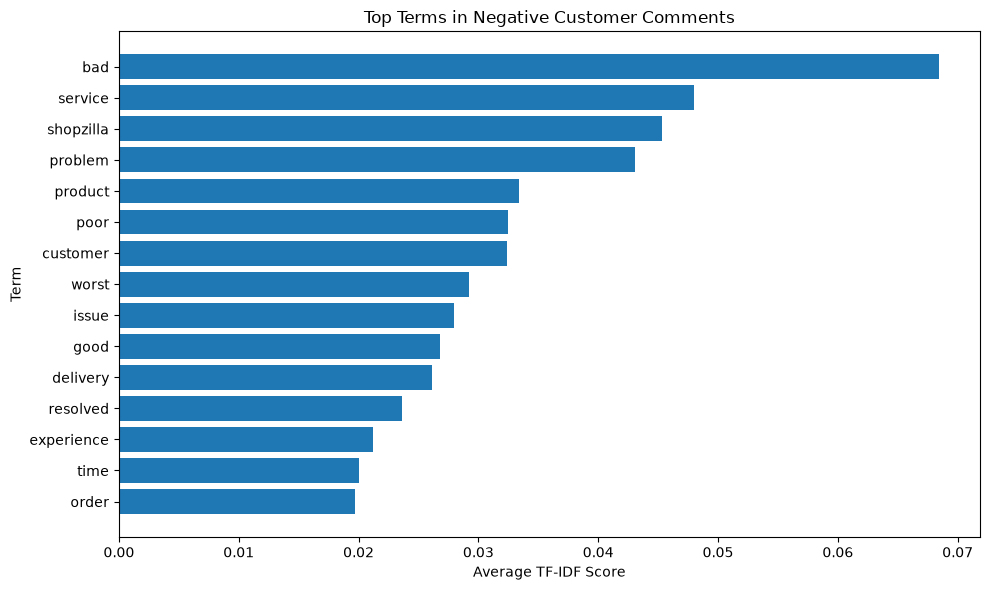

In [160]:
import matplotlib.pyplot as plt

top_terms = (
    tfidf_keywords
    .head(15)
    .sort_values("tfidf_score")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_terms["term"],
    top_terms["tfidf_score"]
)

plt.title(
    "Top Terms in Negative Customer Comments"
)

plt.xlabel("Average TF-IDF Score")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

In [161]:
sentiment_df.to_csv(
    "../data/processed/customer_support_sentiment_scored.csv",
    index=False
)

In [162]:
tfidf_keywords.to_csv(
    "../data/processed/negative_customer_keywords.csv",
    index=False
)

In [163]:
print(sentiment_df.shape)

(28739, 27)


In [164]:
print(sentiment_df.columns.tolist())

['unique_id', 'channel_name', 'category', 'sub_category', 'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at', 'issue_responded', 'survey_response_date', 'customer_city', 'product_category', 'item_price', 'agent_name', 'supervisor', 'manager', 'tenure_bucket', 'agent_shift', 'csat_score', 'response_time_minutes', 'response_time_bucket', 'csat_category', 'has_customer_remark', 'has_order_info', 'has_response_time', 'sentiment_score', 'sentiment']


In [165]:
business_analysis = (
    sentiment_df
    .groupby(["category", "sub_category"])
    .agg(
        total_tickets=("sentiment", "count"),
        negative_tickets=(
            "sentiment",
            lambda x: (x == "Negative").sum()
        ),
        average_csat=("csat_score", "mean"),
        average_response_time=(
            "response_time_minutes",
            "mean"
        )
    )
    .reset_index()
)

In [166]:
business_analysis["negative_rate"] = (
    business_analysis["negative_tickets"]
    / business_analysis["total_tickets"]
    * 100
)

In [167]:
business_analysis = business_analysis.round({
    "negative_rate": 2,
    "average_csat": 2,
    "average_response_time": 2
})

In [168]:
display(business_analysis.head(20))

,category,sub_category,total_tickets,negative_tickets,average_csat,average_response_time,negative_rate
0,App/website,App/website Related,2,0,5.00,33.00,0.00
1,App/website,Issues with Shopzilla App,20,6,4.00,5606.38,30.00
2,Cancellation,Not Needed,625,135,3.62,6841.55,21.60
3,Cancellation,Return cancellation,96,11,4.48,3554.78,11.46
4,Feedback,UnProfessional Behaviour,783,158,3.95,4949.90,20.18
5,Offers & Cashback,Affiliate Offers,45,13,3.42,2167.55,28.89
6,Offers & Cashback,Instant discount,19,2,4.74,4781.33,10.53
7,Offers & Cashback,Other Cashback,80,8,4.14,5402.18,10.00
8,Onboarding related,Commission related,2,1,1.00,NaN,50.00
9,Onboarding related,Seller onboarding,29,4,4.28,3.00,13.79


In [169]:
business_analysis_filtered = business_analysis[
    business_analysis["total_tickets"] >= 50
].copy()

In [170]:
print(
    "Issues with at least 50 tickets:",
    len(business_analysis_filtered)
)

Issues with at least 50 tickets: 31


In [171]:
top_negative_issues = (
    business_analysis_filtered
    .sort_values(
        "negative_rate",
        ascending=False
    )
    .head(15)
)

display(top_negative_issues)

,category,sub_category,total_tickets,negative_tickets,average_csat,average_response_time,negative_rate
18,Order Related,Seller Cancelled Order,452,157,3.27,3458.79,34.73
49,Returns,Technician Visit,147,50,2.93,8173.87,34.01
39,Returns,Exchange / Replacement,282,69,3.73,6250.76,24.47
13,Order Related,Installation/demo,1384,318,3.48,4993.57,22.98
11,Order Related,Delayed,2250,515,3.70,5146.08,22.89
2,Cancellation,Not Needed,625,135,3.62,6841.55,21.60
33,Product Queries,Product Specific Information,1246,268,3.79,4257.37,21.51
12,Order Related,General Enquiry,56,12,3.64,9075.74,21.43
4,Feedback,UnProfessional Behaviour,783,158,3.95,4949.90,20.18
37,Refund Related,Refund Related Issues,552,109,3.91,4709.10,19.75


In [172]:
top_negative_volume = (
    business_analysis_filtered
    .sort_values(
        "negative_tickets",
        ascending=False
    )
    .head(15)
)

display(top_negative_volume)

,category,sub_category,total_tickets,negative_tickets,average_csat,average_response_time,negative_rate
45,Returns,Reverse Pickup Enquiry,7520,1385,3.99,4886.41,18.42
11,Order Related,Delayed,2250,515,3.70,5146.08,22.89
16,Order Related,Order status enquiry,2389,388,4.09,2125.51,16.24
13,Order Related,Installation/demo,1384,318,3.48,4993.57,22.98
44,Returns,Return request,3039,307,4.60,2988.72,10.10
33,Product Queries,Product Specific Information,1246,268,3.79,4257.37,21.51
4,Feedback,UnProfessional Behaviour,783,158,3.95,4949.90,20.18
18,Order Related,Seller Cancelled Order,452,157,3.27,3458.79,34.73
40,Returns,Fraudulent User,1290,148,4.60,5362.74,11.47
2,Cancellation,Not Needed,625,135,3.62,6841.55,21.60


In [173]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

business_analysis_filtered[
    [
        "negative_volume_score",
        "negative_rate_score",
        "csat_problem_score"
    ]
] = scaler.fit_transform(
    business_analysis_filtered[
        [
            "negative_tickets",
            "negative_rate",
            "average_csat"
        ]
    ]
)

In [174]:
business_analysis_filtered["csat_problem_score"] = (
    1 - business_analysis_filtered["csat_problem_score"]
)

In [175]:
business_analysis_filtered["priority_score"] = (
    0.4 * business_analysis_filtered["negative_volume_score"]
    + 0.4 * business_analysis_filtered["negative_rate_score"]
    + 0.2 * business_analysis_filtered["csat_problem_score"]
)

In [176]:
priority_issues = (
    business_analysis_filtered
    .sort_values(
        "priority_score",
        ascending=False
    )
    .head(15)
)

In [177]:
display(
    priority_issues[
        [
            "category",
            "sub_category",
            "total_tickets",
            "negative_tickets",
            "negative_rate",
            "average_csat",
            "average_response_time",
            "priority_score"
        ]
    ].round(2)
)

,category,sub_category,total_tickets,negative_tickets,negative_rate,average_csat,average_response_time,priority_score
45,Returns,Reverse Pickup Enquiry,7520,1385,18.42,3.99,4886.41,0.64
18,Order Related,Seller Cancelled Order,452,157,34.73,3.27,3458.79,0.60
49,Returns,Technician Visit,147,50,34.01,2.93,8173.87,0.60
11,Order Related,Delayed,2250,515,22.89,3.70,5146.08,0.49
13,Order Related,Installation/demo,1384,318,22.98,3.48,4993.57,0.46
33,Product Queries,Product Specific Information,1246,268,21.51,3.79,4257.37,0.38
39,Returns,Exchange / Replacement,282,69,24.47,3.73,6250.76,0.38
2,Cancellation,Not Needed,625,135,21.60,3.62,6841.55,0.37
12,Order Related,General Enquiry,56,12,21.43,3.64,9075.74,0.33
4,Feedback,UnProfessional Behaviour,783,158,20.18,3.95,4949.90,0.31


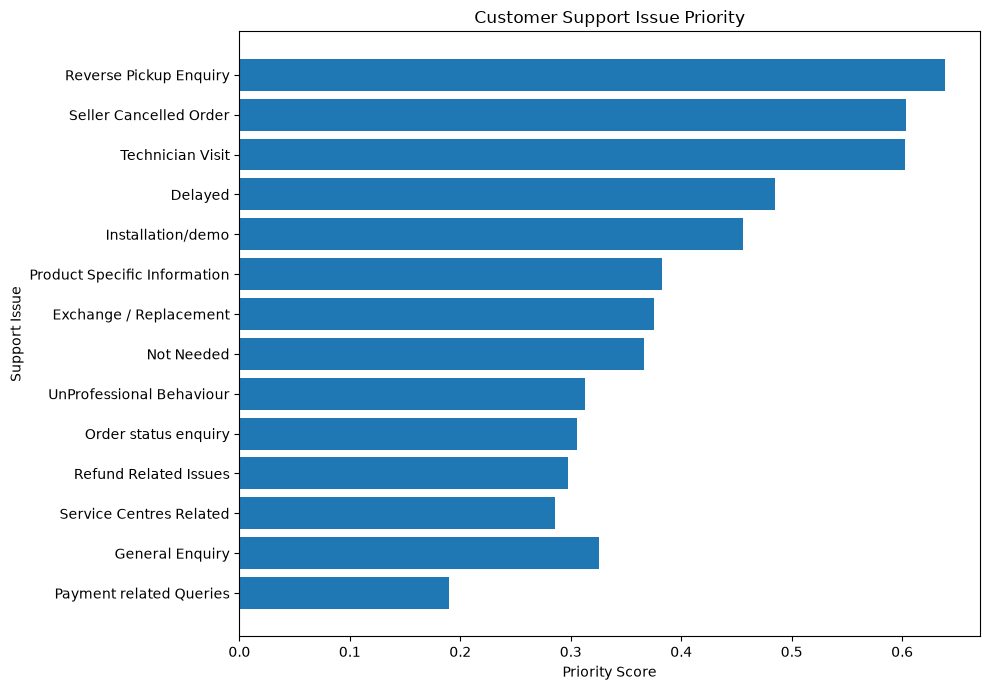

In [178]:
import matplotlib.pyplot as plt

plot_data = (
    priority_issues
    .sort_values("priority_score")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["sub_category"],
    plot_data["priority_score"]
)

plt.xlabel("Priority Score")
plt.ylabel("Support Issue")
plt.title("Customer Support Issue Priority")

plt.tight_layout()
plt.show()

In [179]:
sentiment_df["response_time_group"] = pd.cut(
    sentiment_df["response_time_minutes"],
    bins=[0, 30, 60, 120, 240, 480, float("inf")],
    labels=[
        "0-30 min",
        "30-60 min",
        "1-2 hours",
        "2-4 hours",
        "4-8 hours",
        "8+ hours"
    ]
)

In [180]:
response_analysis = (
    sentiment_df
    .groupby("response_time_group", observed=True)
    .agg(
        total_tickets=("sentiment", "count"),
        negative_tickets=(
            "sentiment",
            lambda x: (x == "Negative").sum()
        ),
        average_csat=("csat_score", "mean")
    )
)

In [181]:
response_analysis["negative_rate"] = (
    response_analysis["negative_tickets"]
    / response_analysis["total_tickets"]
    * 100
)

In [182]:
display(response_analysis.round(2))

,total_tickets,negative_tickets,average_csat,negative_rate
response_time_group,,,,
0-30 min,7439,1064,4.24,14.30
30-60 min,595,138,3.57,23.19
1-2 hours,458,127,3.52,27.73
2-4 hours,430,116,3.43,26.98
4-8 hours,290,72,3.45,24.83
8+ hours,963,270,3.31,28.04


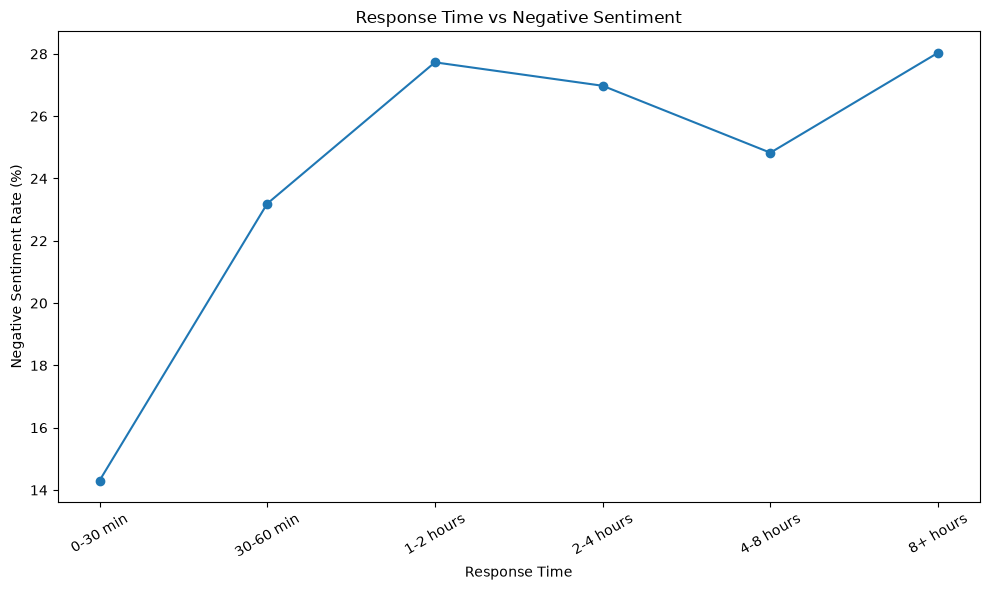

In [183]:
plt.figure(figsize=(10, 6))

plt.plot(
    response_analysis.index.astype(str),
    response_analysis["negative_rate"],
    marker="o"
)

plt.xlabel("Response Time")
plt.ylabel("Negative Sentiment Rate (%)")
plt.title("Response Time vs Negative Sentiment")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [184]:
business_analysis_filtered.to_csv(
    "../data/processed/customer_support_business_analysis.csv",
    index=False
)

In [185]:
response_analysis.to_csv(
    "../data/processed/response_time_sentiment_analysis.csv"
)

In [186]:
print(sentiment_df.shape)

(28739, 28)


In [187]:
print(sentiment_df.columns.tolist())


['unique_id', 'channel_name', 'category', 'sub_category', 'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at', 'issue_responded', 'survey_response_date', 'customer_city', 'product_category', 'item_price', 'agent_name', 'supervisor', 'manager', 'tenure_bucket', 'agent_shift', 'csat_score', 'response_time_minutes', 'response_time_bucket', 'csat_category', 'has_customer_remark', 'has_order_info', 'has_response_time', 'sentiment_score', 'sentiment', 'response_time_group']


In [188]:
from scipy.stats import pearsonr, spearmanr

In [189]:
sentiment_csat_data = sentiment_df[
    ["sentiment_score", "csat_score"]
].dropna()

In [190]:
correlation, p_value = pearsonr(
    sentiment_csat_data["sentiment_score"],
    sentiment_csat_data["csat_score"]
)

print("Pearson correlation:", round(correlation, 3))
print("P-value:", round(p_value, 5))

Pearson correlation: 0.535
P-value: 0.0


| Correlation | General interpretation        |
| ----------: | ----------------------------- |
|        -0.7 | Strong negative relationship  |
|        -0.3 | Moderate negative             |
|           0 | Little/no linear relationship |
|        +0.3 | Moderate positive             |
|        +0.7 | Strong positive               |


In [191]:
response_sentiment_data = sentiment_df[
    ["response_time_minutes", "sentiment_score"]
].dropna()

In [192]:
correlation, p_value = spearmanr(
    response_sentiment_data["response_time_minutes"],
    response_sentiment_data["sentiment_score"]
)

print("Spearman correlation:", round(correlation, 3))
print("P-value:", round(p_value, 5))

Spearman correlation: -0.147
P-value: 0.0


In [193]:
from scipy.stats import pearsonr, spearmanr, f_oneway

In [194]:
category_counts = sentiment_df["category"].value_counts()

valid_categories = category_counts[
    category_counts >= 50
].index

In [195]:
category_data = sentiment_df[
    sentiment_df["category"].isin(valid_categories)
]

In [196]:
groups = [
    group["sentiment_score"].dropna().values
    for _, group in category_data.groupby("category")
]

In [197]:
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", round(f_stat, 3))
print("P-value:", round(p_value, 5))

F-statistic: 25.057
P-value: 0.0


In [198]:
category_sentiment = (
    category_data
    .groupby("category")
    .agg(
        ticket_count=("sentiment_score", "count"),
        average_sentiment=("sentiment_score", "mean"),
        average_csat=("csat_score", "mean")
    )
    .sort_values(
        "average_sentiment"
    )
)

display(category_sentiment.round(3))

,ticket_count,average_sentiment,average_csat
category,,,
Product Queries,1282,0.194,3.793
Cancellation,721,0.208,3.738
Order Related,7630,0.212,3.852
Feedback,783,0.214,3.953
Refund Related,1487,0.264,4.106
Offers & Cashback,144,0.271,3.993
Returns,14836,0.276,4.217
Shopzilla Related,981,0.300,4.159
Payments related,780,0.304,4.282


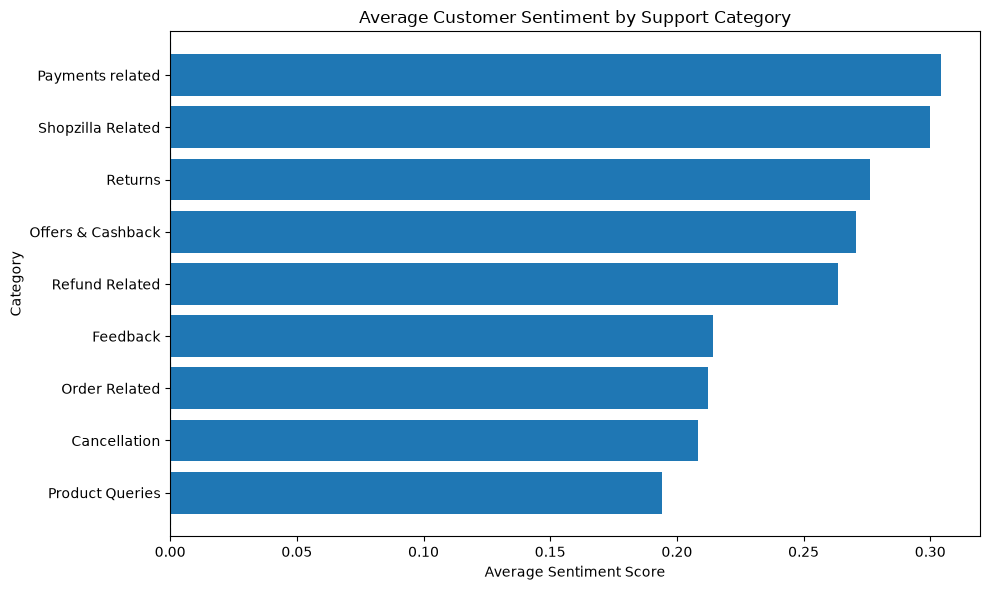

In [199]:
import matplotlib.pyplot as plt

plot_data = (
    category_sentiment
    .sort_values("average_sentiment")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data.index,
    plot_data["average_sentiment"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Average Sentiment Score")
plt.ylabel("Category")
plt.title("Average Customer Sentiment by Support Category")

plt.tight_layout()
plt.show()

In [200]:
statistical_results = pd.DataFrame({
    "test": [
        "Sentiment vs CSAT",
        "Response Time vs Sentiment",
        "Sentiment across Categories"
    ],
    "statistic": [
        correlation,
        correlation,
        f_stat
    ],
    "p_value": [
        p_value,
        p_value,
        p_value
    ]
})

In [201]:
csat_corr, csat_p = pearsonr(
    sentiment_csat_data["sentiment_score"],
    sentiment_csat_data["csat_score"]
)

In [202]:
anova_f, anova_p = f_oneway(*groups)

In [204]:
from scipy.stats import spearmanr

response_sentiment_data = sentiment_df[
    ["response_time_minutes", "sentiment_score"]
].dropna()

response_corr, response_p = spearmanr(
    response_sentiment_data["response_time_minutes"],
    response_sentiment_data["sentiment_score"]
)

print("Response Time vs Sentiment")
print("Spearman correlation:", round(response_corr, 3))
print("P-value:", round(response_p, 5))

Response Time vs Sentiment
Spearman correlation: -0.147
P-value: 0.0


In [205]:
print("CSAT correlation:", csat_corr)
print("CSAT p-value:", csat_p)

print("Response correlation:", response_corr)
print("Response p-value:", response_p)

print("ANOVA F:", anova_f)
print("ANOVA p-value:", anova_p)

CSAT correlation: 0.5353721847344297
CSAT p-value: 0.0
Response correlation: -0.14659487090849443
Response p-value: 3.119677315322542e-51
ANOVA F: 25.057220356929452
ANOVA p-value: 7.108619727346376e-39


In [206]:
statistical_results = pd.DataFrame({
    "test": [
        "Sentiment vs CSAT",
        "Response Time vs Sentiment",
        "Sentiment across Categories"
    ],
    "statistic": [
        csat_corr,
        response_corr,
        anova_f
    ],
    "p_value": [
        csat_p,
        response_p,
        anova_p
    ]
})

display(statistical_results.round(5))

,test,statistic,p_value
0,Sentiment vs CSAT,0.53537,0.0
1,Response Time vs Sentiment,-0.14659,0.0
2,Sentiment across Categories,25.05722,0.0


In [207]:
statistical_results.to_csv(
    "../data/processed/statistical_validation_results.csv",
    index=False
)